# A Pedagogical DHO Notebook for HQPINN

This notebook focuses exclusively on the `DHO` benchmark from Appendix A.2 of *Hybrid Quantum Physics-informed Neural Network: Towards Efficient Learning of High-speed Flows*.

The notebook is organized around a simple storyline:
- start from the governing equation used in the paper;
- explain the PINN loss used for `DHO`;
- compare the seven variants in the order `cc`, `qq-pl`, `hy-pl`, `qq-m`, `qq-mp`, `hy-m`, `hy-mp`;
- keep the training loop front and center;
- end with a compact comparison of runtime, parameter count, and final loss.

CLI details, checkpoint management, PNG exports, and the other benchmarks are intentionally kept in the background.


In [17]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "HQPINN" / "configs").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from the current working directory.")


REPO_ROOT = resolve_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from HQPINN.notebook_dho_helpers import *


## 1. The DHO Benchmark in the Paper

In Appendix A.2, the paper studies the damped harmonic oscillator

$$
m u''(t) + \mu u'(t) + k u(t) = 0,
\qquad t \in (0, 1],
$$

with

$$
u(0) = 1,
\qquad
u'(0) = 0.
$$

In this reproduction, we keep the same constants as in the code:

$$
m = 1,
\qquad
\mu = 4,
\qquad
k = 400.
$$

The key idea for reading this notebook is that **all models are trained against the same physics and the same loss**. What changes across the paper's variants is the choice of the two branches that are fused at the end.

The DHO loss implemented in the code is

$$
\mathcal{L} = \mathcal{L}_{IC,u} + \lambda_1 \mathcal{L}_{IC,u'} + \lambda_2 \mathcal{L}_{PDE},
$$

with

$$
\mathcal{L}_{IC,u} = (u_\theta(0) - 1)^2,
\qquad
\mathcal{L}_{IC,u'} = (u'_\theta(0))^2,
$$

and

$$
\mathcal{L}_{PDE} = \frac{1}{N}\sum_i
\left(m u''_\theta(t_i) + \mu u'_\theta(t_i) + k u_\theta(t_i)\right)^2.
$$

This makes `DHO` a useful introductory case study: the physics is simple, the loss is short, and the comparison between classical, hybrid, and quantum branches is easy to see.


DHO constants
------------------------------------------------------------------------
m=1.0, mu=4.0, k=400.0

Training setup used in this reproduction
------------------------------------------------------------------------
optimizer                : Adam
learning rate            : 0.002
epochs                   : 1801
logging / curve          : one point every 100 epochs
time grid                : 200 points on [0, 1]
interior training points : 199 (t=0 handled separately)
loss weights             : lambda1=0.1, lambda2=0.0001
dtype                    : torch.float64


### Variants Compared in This Notebook

| Order | Code | Branch 1 | Branch 2 | Size used in this reproduction |
|---|---|---|---|---|
| 1 | `cc` | classical | classical | `16-2` |
| 2 | `qq-pl` | quantum PennyLane | quantum PennyLane | `3` |
| 3 | `hy-pl` | quantum PennyLane | classical | `16-2-3` |
| 4 | `qq-m` | quantum Merlin | quantum Merlin | `1` |
| 5 | `qq-mp` | quantum Perceval | quantum Perceval | `default` |
| 6 | `hy-m` | quantum Merlin | classical | `16-2-1` |
| 7 | `hy-mp` | quantum Perceval | classical | `16-2` |

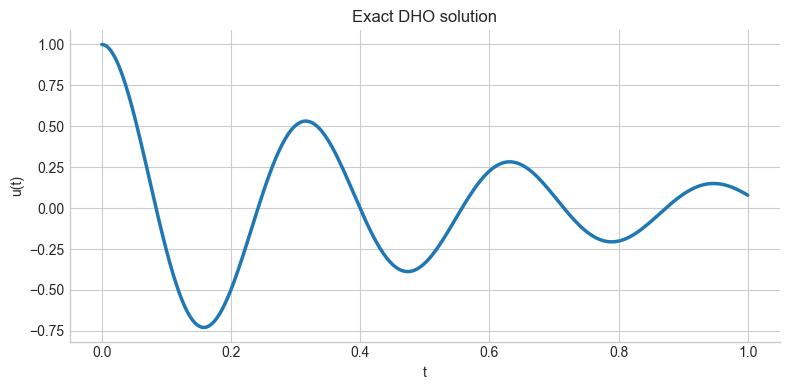

In [18]:
t_train = make_time_grid()
t_exact = np.linspace(0.0, 1.0, 400)
u_ref = u_exact(t_exact)

print("DHO constants")
print("-" * 72)
print(f"m={M}, mu={MU}, k={K}")
print()
print("Training setup used in this reproduction")
print("-" * 72)
print(f"optimizer                : Adam")
print(f"learning rate            : {DHO_LR}")
print(f"epochs                   : {DHO_N_EPOCHS}")
print(f"logging / curve          : one point every {DHO_PLOT_EVERY} epochs")
print(f"time grid                : {DHO_N_SAMPLES} points on [0, 1]")
print(f"interior training points : {int(t_train.shape[0])} (t=0 handled separately)")
print(f"loss weights             : lambda1={LAMBDA1}, lambda2={LAMBDA2}")
print(f"dtype                    : {DTYPE}")

display(Markdown("### Variants Compared in This Notebook"))
display(Markdown(model_overview_markdown()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_exact, u_ref, color="#1f77b4", linewidth=2.5)
ax.set_title("Exact DHO solution")
ax.set_xlabel("t")
ax.set_ylabel("u(t)")
fig.tight_layout()
plt.show()


### From Paper to Code: the DHO Loss

The next cell translates the equation above into code as directly as possible.
It keeps only the three ingredients that matter for understanding the paper:
- the network prediction `u_\theta(t)`;
- the derivatives obtained with autograd;
- the three loss terms used in the DHO benchmark.

This is the notebook-facing version of the same logic used in [the core implementation](HQPINN/lib/DHO/core_dho.py).


In [ ]:
def dho_loss_from_paper(model, t):
    """Minimal DHO loss written to mirror the paper equation."""
    # Make the time grid differentiable so autograd can compute u'(t) and u''(t).
    t = t.clone().detach().requires_grad_(True)

    # Neural network prediction u_theta(t).
    u = model(t)

    # Automatic differentiation gives the first and second derivatives.
    du = derivative(u, t)
    d2u = second_derivative(u, t)

    # Physics residual from the paper: m u'' + mu u' + k u.
    residual = M * d2u + MU * du + K * u

    # Initial conditions are enforced at t = 0.
    t0 = torch.zeros((1, 1), dtype=DTYPE, device=DEVICE).requires_grad_(True)
    u0 = model(t0)
    du0 = derivative(u0, t0)

    loss_ic_u = (u0 - 1.0) ** 2
    loss_ic_du = du0**2
    loss_pde = torch.mean(residual**2)

    return (
        loss_ic_u.squeeze(),
        loss_ic_du.squeeze(),
        loss_pde.squeeze(),
    )


## 2. The Training Loop at the Center

The loss is now defined just above in notebook form, and the next cell shows how it is used inside the shared training loop.

Every model follows the exact same logic:
1. build the model;
2. evaluate the three DHO loss terms;
3. assemble the total loss;
4. apply the Adam update;
5. store the history for the learning curve.

In other words, the comparison in the paper becomes very easy to read: **the loop stays the same, and only the architecture changes**.


In [19]:
def train_one_model(
    spec: dict[str, object],
    *,
    epochs: int = DHO_N_EPOCHS,
    lr: float = DHO_LR,
    log_every: int = DHO_PLOT_EVERY,
) -> dict[str, object]:
    """Train one DHO variant using the same PINN loop for every model."""
    seed_everything(0)
    model = build_model(spec)
    model.train()

    t_train = make_time_grid()
    optimizer = make_optimizer(model, lr=lr)
    history: list[dict[str, float]] = []
    start = perf_counter()

    for epoch in range(epochs):
        optimizer.zero_grad()

        # 1) The three terms used in the paper: two initial conditions + one physics residual.
        loss_ic_u, loss_ic_du, loss_pde = dho_loss_from_paper(model, t_train)

        # 2) The total loss combines them with the reproduction weights.
        loss = loss_ic_u + LAMBDA1 * loss_ic_du + LAMBDA2 * loss_pde

        # 3) Backpropagation and parameter update.
        loss.backward()
        optimizer.step()

        # 4) Keep a lightweight history for the learning curve.
        if epoch % log_every == 0 or epoch == epochs - 1:
            history.append(
                {
                    "epoch": epoch,
                    "elapsed_s": perf_counter() - start,
                    "loss": float(loss.item()),
                    "ic_u": float(loss_ic_u.item()),
                    "ic_du": float(loss_ic_du.item()),
                    "pde": float(loss_pde.item()),
                }
            )

    return {
        "name": spec["name"],
        "paper_label": spec["paper_label"],
        "branch_1": spec["branch_1"],
        "branch_2": spec["branch_2"],
        "branches": spec["branches"],
        "color": spec["color"],
        "case_prefix": spec["case_prefix"],
        "spec": spec,
        "size": spec["size_hint"],
        "params": count_trainable_params(model),
        "elapsed_s": history[-1]["elapsed_s"],
        "final_loss": history[-1]["loss"],
        "history": history,
        "source": "run computed in this notebook",
        "run_id": None,
        "model": model,
    }


def run_dho_case(
    spec: dict[str, object],
    *,
    run_training: bool,
    epochs: int = DHO_N_EPOCHS,
) -> dict[str, object]:
    if run_training:
        return train_one_model(spec, epochs=epochs)
    return load_saved_case(spec)


## 3. One Learning Loop per Model

By default, the notebook reloads the **latest saved histories** so that it stays lightweight and immediately readable.

For each model, the notebook now shows both the learning curve and the trajectory `u(t)` against the exact DHO solution.
If you want to rerun training directly from the notebook, set `RUN_TRAINING = True` in the next cell. The most expensive cases are `qq-pl` and then `hy-pl`, so this mode is mainly intended for a longer run.


**Execution mode:** reload the latest saved histories.

### CC (`cc`)

Branches : classical + classical
Source   : latest saved run (20260403-185410)
Runtime  : 2.74 s | Parameters : 721 | Final loss : 3.6180e-02


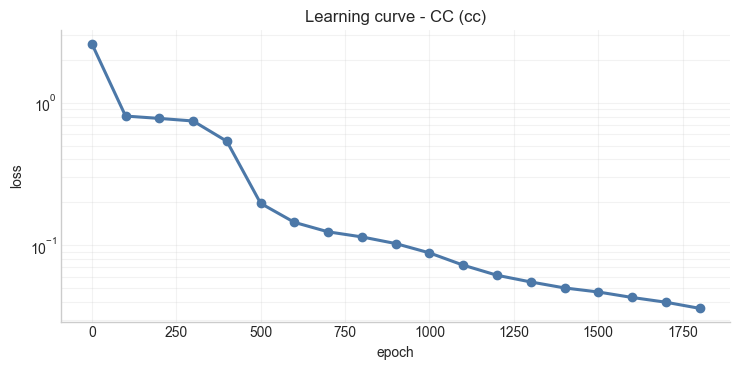

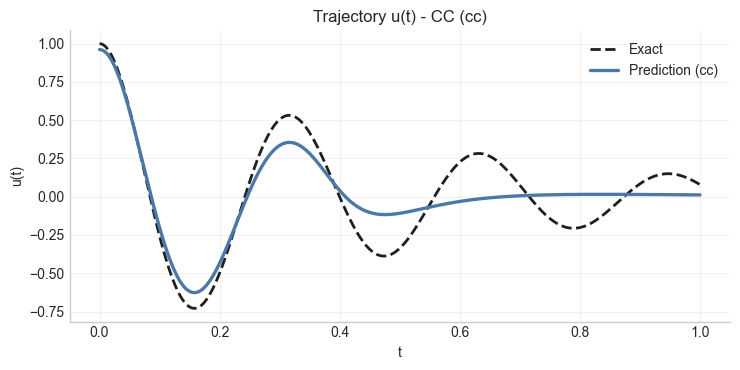

### QQ-PL (`qq-pl`)

Branches : quantum PennyLane + quantum PennyLane
Source   : latest saved run (20260403-220050)
Runtime  : 2.48 h | Parameters : 57 | Final loss : 5.6532e-04


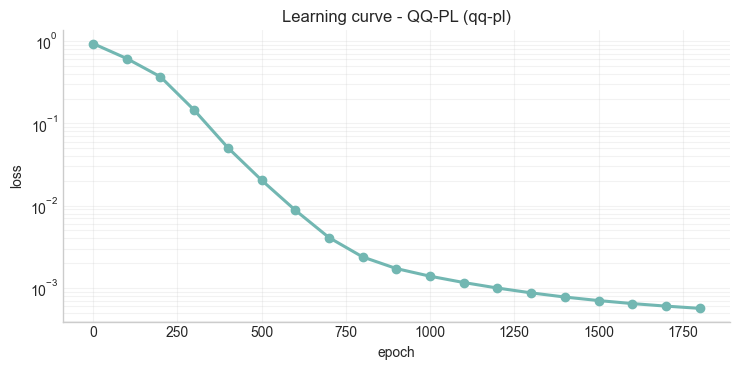

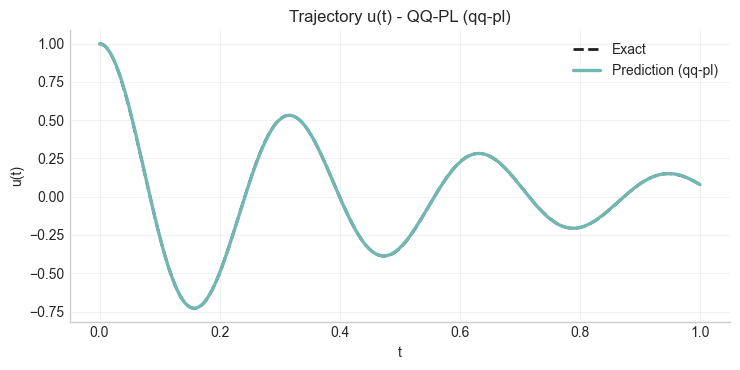

### HY-PL (`hy-pl`)

Branches : quantum PennyLane + classical
Source   : latest saved run (20260403-204813)
Runtime  : 1.13 h | Parameters : 353 | Final loss : 2.2967e-02


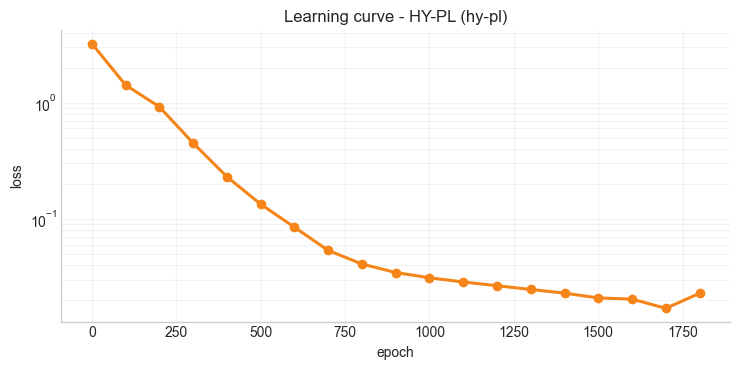

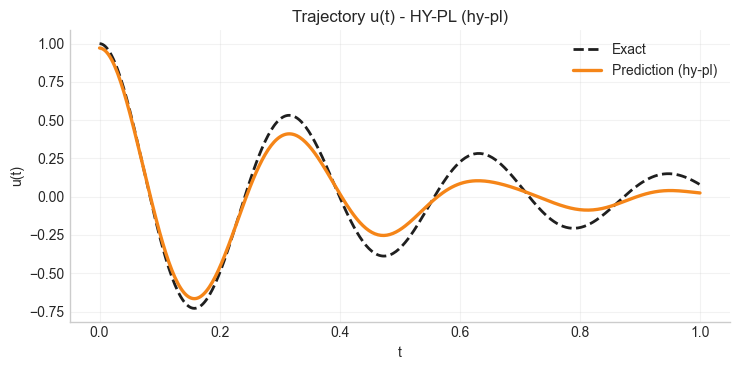

### QQ-M (`qq-m`)

Branches : quantum Merlin + quantum Merlin
Source   : latest saved run (20260403-215611)
Runtime  : 2.7 min | Parameters : 197 | Final loss : 9.1958e-03


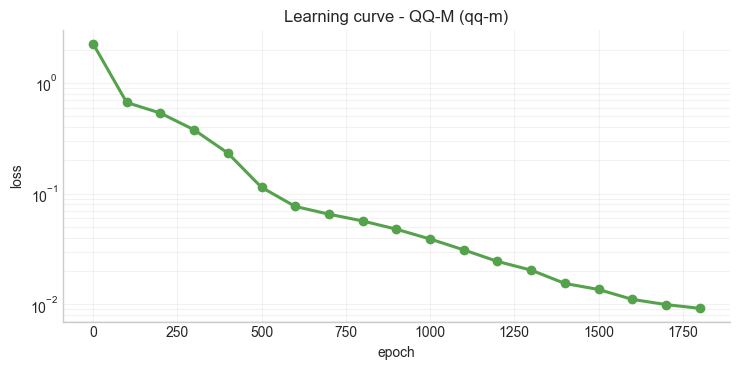

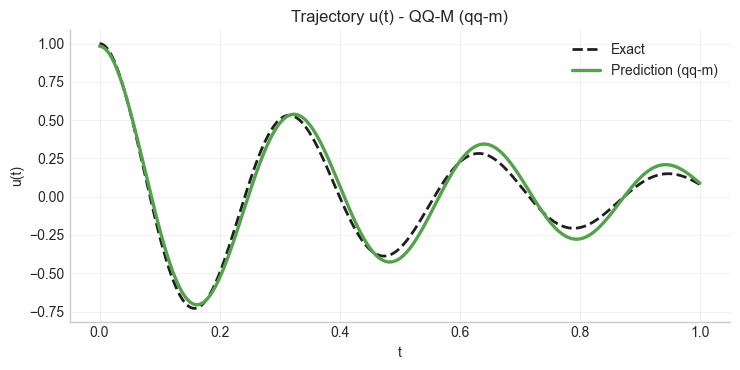

### QQ-MP (`qq-mp`)

Branches : quantum Perceval + quantum Perceval
Source   : latest saved run (20260403-215855)
Runtime  : 1.8 min | Parameters : 71 | Final loss : 5.9419e-04


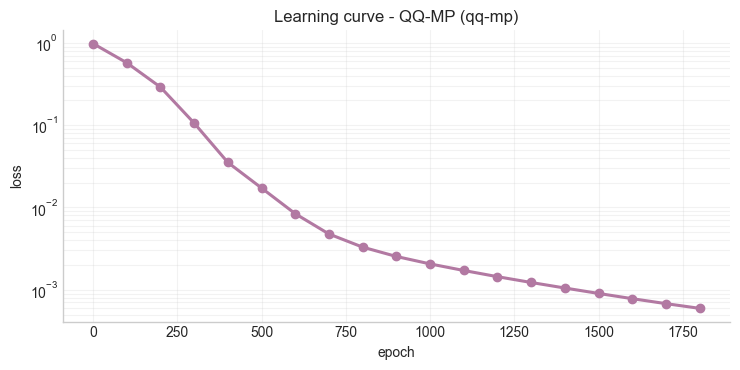

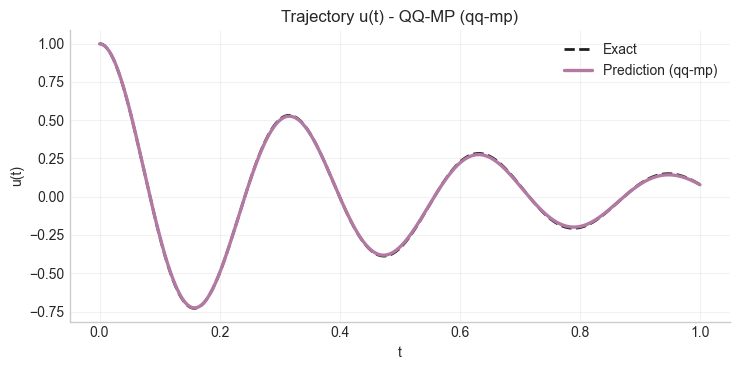

### HY-M (`hy-m`)

Branches : quantum Merlin + classical
Source   : latest saved run (20260403-185703)
Runtime  : 56.7 min | Parameters : 423 | Final loss : 4.7615e-02


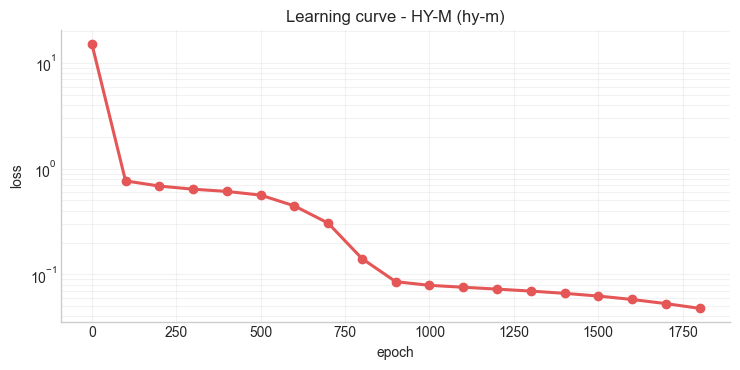

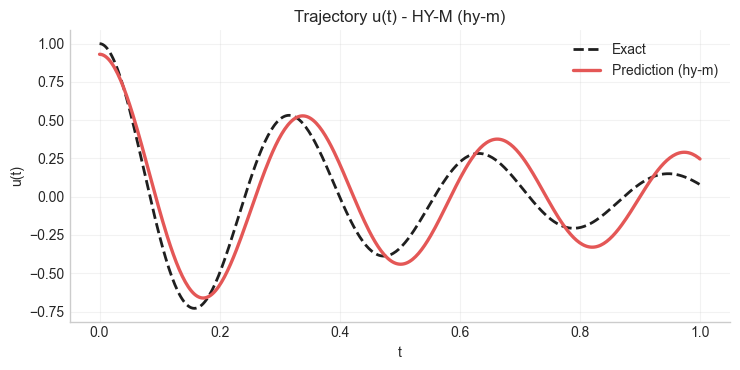

### HY-MP (`hy-mp`)

Branches : quantum Perceval + classical
Source   : latest saved run (20260403-185415)
Runtime  : 2.8 min | Parameters : 360 | Final loss : 1.1835e-02


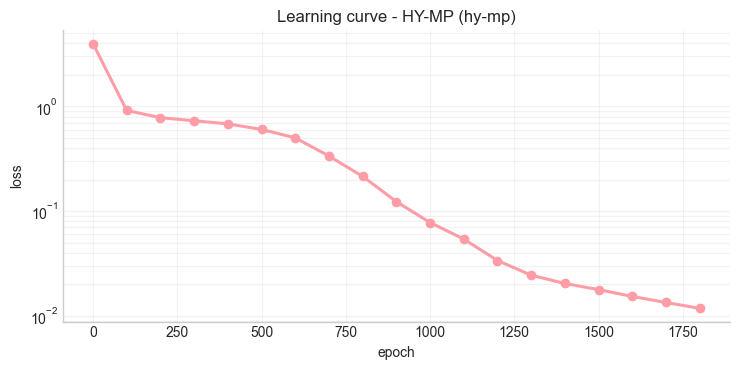

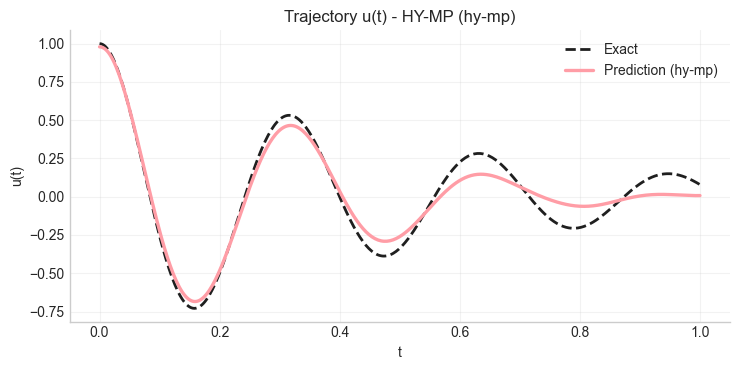

In [20]:
RUN_TRAINING = False
EPOCHS_TO_RUN = DHO_N_EPOCHS

mode_label = (
    "full training in this notebook"
    if RUN_TRAINING
    else "reload the latest saved histories"
)
display(Markdown(f"**Execution mode:** {mode_label}."))

results = []
for spec in MODEL_SPECS:
    result = run_dho_case(spec, run_training=RUN_TRAINING, epochs=EPOCHS_TO_RUN)
    results.append(result)
    display_case_report(result)


## 4. Final Comparison Across the Seven Models

We end with the three quantities that matter most for reading the trade-offs reported in the paper for `DHO`:
- **runtime**;
- **number of trainable parameters**;
- **final loss**.

If `RUN_TRAINING=False`, the comparison uses the latest saved runs in `HQPINN/results/DHO/`. Otherwise, it uses the current notebook session.


| Order | Model | Branches | Size | Parameters | Runtime (s) | Final loss |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | `cc` | MLP + MLP | `16-2` | 721 | 2.74 | 3.6180e-02 |
| 2 | `qq-pl` | PQC + PQC | `3` | 57 | 8921.34 | 5.6532e-04 |
| 3 | `hy-pl` | PQC + MLP | `16-2-3` | 353 | 4061.40 | 2.2967e-02 |
| 4 | `qq-m` | interferometer + interferometer | `1` | 197 | 159.55 | 9.1958e-03 |
| 5 | `qq-mp` | Perceval + Perceval | `default` | 71 | 107.67 | 5.9419e-04 |
| 6 | `hy-m` | interferometer + MLP | `16-2-1` | 423 | 3399.16 | 4.7615e-02 |
| 7 | `hy-mp` | Perceval + MLP | `16-2` | 360 | 165.72 | 1.1835e-02 |

- **Fastest runtime**: `cc` (2.74 s)
- **Smallest model**: `qq-pl` (57 parameters)
- **Lowest final loss**: `qq-pl` (5.6532e-04)

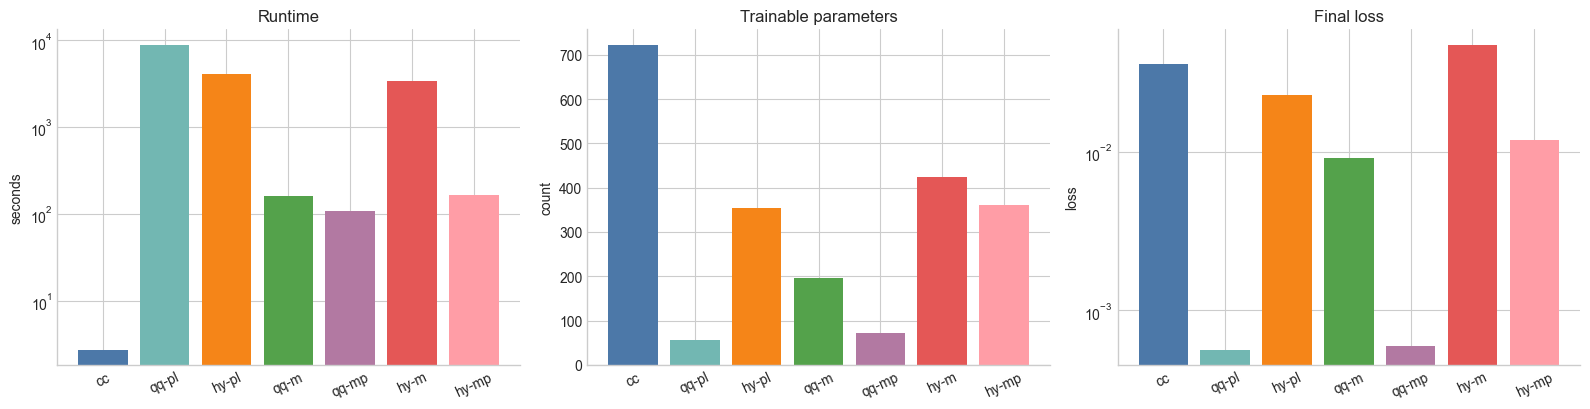

In [21]:
display_final_comparison(results)
